In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

Load and Look at Data

In [7]:
credit_df = pd.read_csv("creditcard.csv.zip")

print(f"Training data shape: {credit_df.shape}")
credit_df.head()

Training data shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [8]:
print("A). \nMissing values in Training")
print(credit_df.isnull().sum())

print("\nB). \nDatatypes in Training:")
print(credit_df.dtypes)

print("\nC). \nBasic statistics (Training):")
print(credit_df.describe())

A). 
Missing values in Training
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

B). 
Datatypes in Training:
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       in

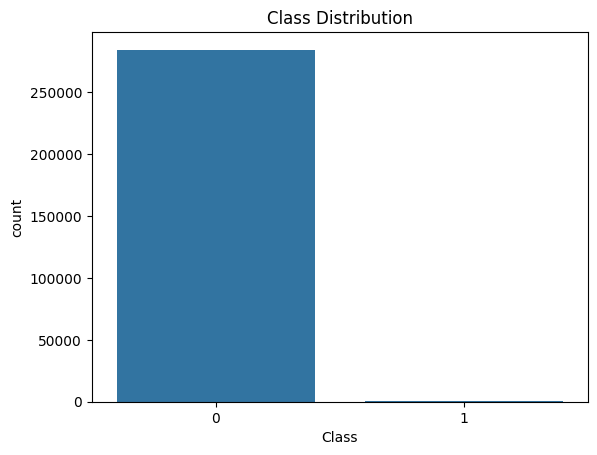

In [9]:
# Class Distribution - This dataset is extremely imbalanced
# This imbalance can bias models toward predicting the majority class, making
# accuracy an unreliable metric.
credit_df['Class'].value_counts()
credit_df['Class'].value_counts(normalize=True)

sns.countplot(x='Class', data=credit_df)
plt.title("Class Distribution")
plt.show()

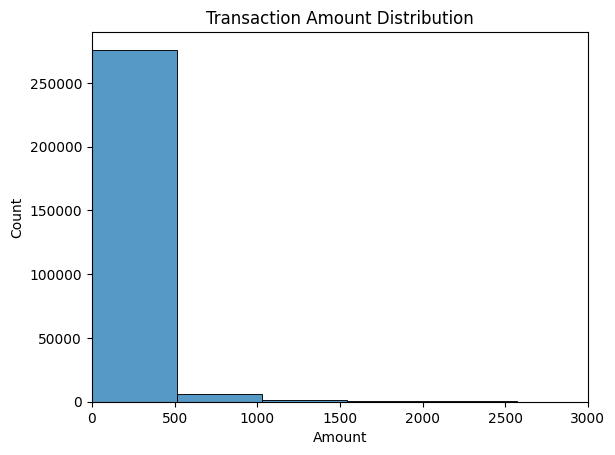

In [10]:
# The distribution of transaction amounts is highly right-skewed,
# with most transactions being small and a few very large ones
sns.histplot(credit_df['Amount'], bins=50)
plt.xlim(0, 3000)
plt.title("Transaction Amount Distribution")
plt.show()


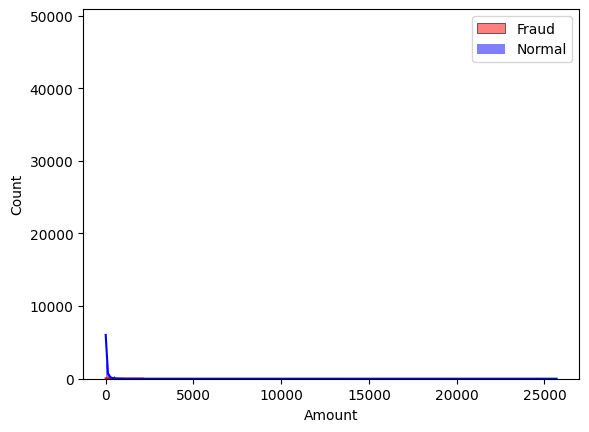

In [11]:
fraud = credit_df[credit_df['Class'] == 1]
normal = credit_df[credit_df['Class'] == 0]

sns.histplot(fraud['Amount'], color='red', label='Fraud', kde=True)
sns.histplot(normal['Amount'], color='blue', label='Normal', kde=True)
plt.legend()
plt.show()

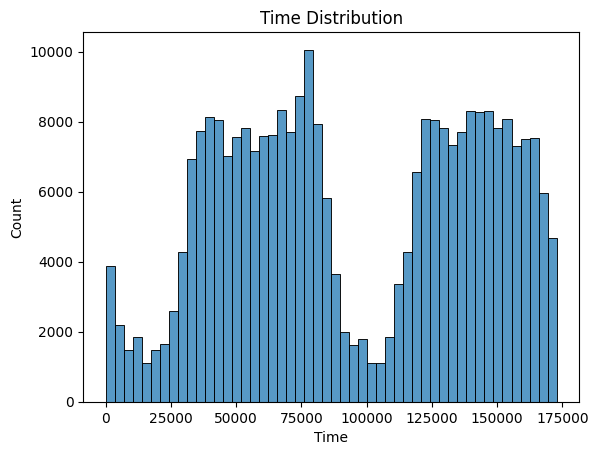

In [12]:
sns.histplot(credit_df['Time'], bins=50)
plt.title("Time Distribution")
plt.show()

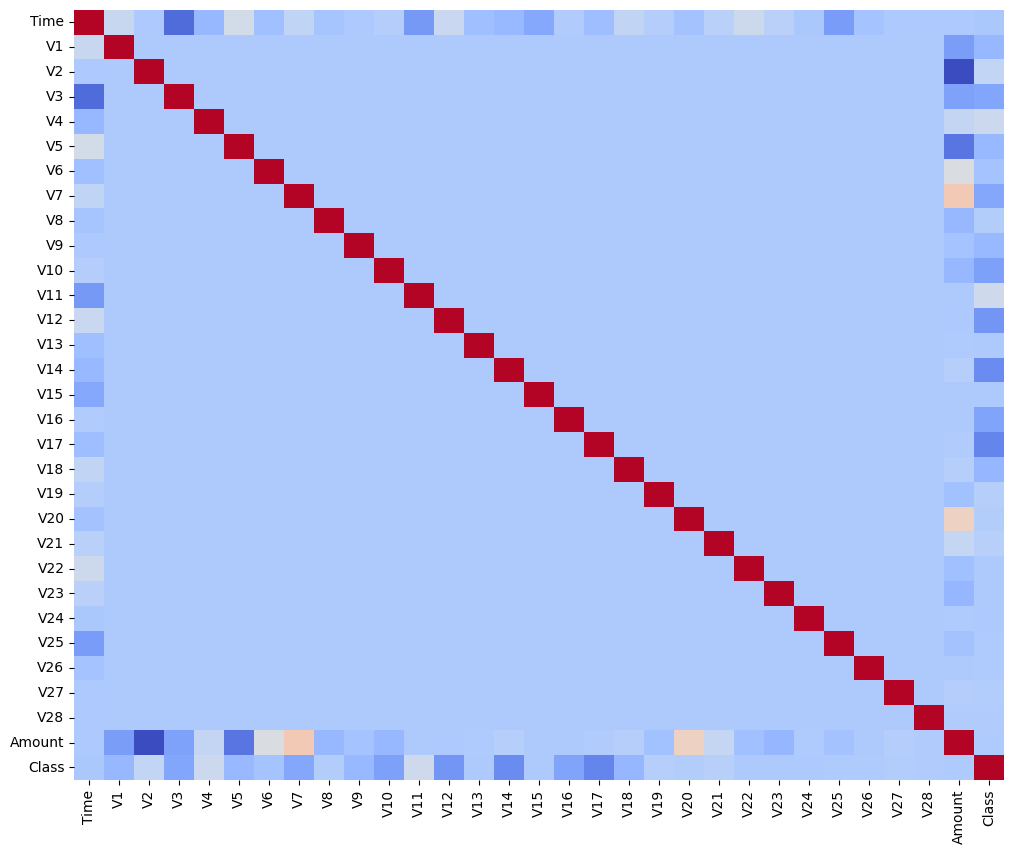

In [ ]:
plt.figure(figsize=(12,10))
sns.heatmap(credit_df.corr(), cmap='coolwarm', cbar=False)
plt.show()

In [ ]:
credit_df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


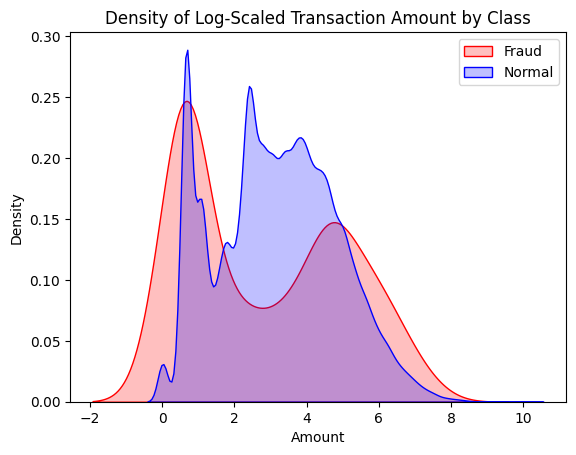

Normal transactions Amount stats:
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

Fraud transactions Amount stats:
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


In [ ]:


sns.kdeplot(np.log1p(fraud['Amount']), color='red', label='Fraud', fill=True)
sns.kdeplot(np.log1p(normal['Amount']), color='blue', label='Normal', fill=True)
plt.legend()
plt.title("Density of Log-Scaled Transaction Amount by Class")
plt.show()

print("Normal transactions Amount stats:")
print(normal['Amount'].describe())
print("\nFraud transactions Amount stats:")
print(fraud['Amount'].describe())



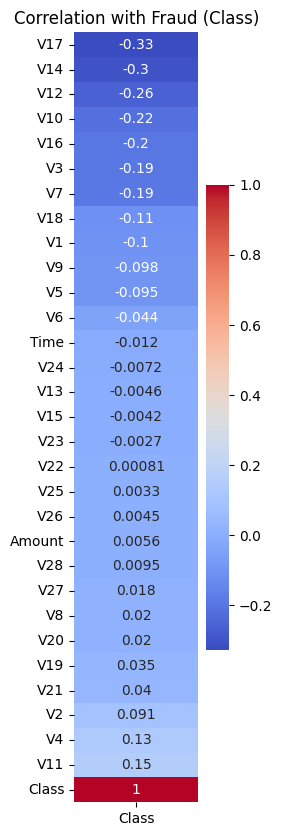

In [13]:
plt.figure(figsize=(2,10))
sns.heatmap(credit_df.corr()[['Class']].sort_values(by='Class'),
            cmap='coolwarm',
            annot=True)
plt.title("Correlation with Fraud (Class)")
plt.show()